# Final

In [2]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
from shutil import copyfile, rmtree
from tqdm import tqdm
import time

import tensorflow as tf
from tensorflow.keras import Model, layers, callbacks
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

# =================== REPRODUCIBILITY ===================
SEED = 40
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15

# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))

# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'],
                                  [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS (NO RESCALING) ===================

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =================== MODEL ===================
def build_model():
    base_model = InceptionResNetV2(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = True  

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.6)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_model()

# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-4,
    decay_steps=1000,
    alpha=1e-6
)

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)

loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'inceptionresnetv2.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)

earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

# ==================== TRAIN ====================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_train_time = end_time - start_time
epoch_count = len(history.history['loss'])
avg_epoch_time = total_train_time / epoch_count

print(f"\n🕒 Total training time: {total_train_time:.2f} seconds")
print(f"⏱️ Average time per epoch: {avg_epoch_time:.2f} seconds")

# ==================== EVALUATION ====================
model.load_weights("inceptionresnetv2.keras")

test_loss, test_acc = model.evaluate(test_generator)

print(f"\n✅ Test Accuracy: {test_acc:.4f}")

1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:00<00:00, 771.89it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Epoch 1/60


I0000 00:00:1770726176.393693     123 service.cc:148] XLA service 0x7a15c0005d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770726176.394727     123 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770726176.394755     123 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770726195.243917     123 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1770726254.355753     123 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7833 - loss: 0.7913
Epoch 1: val_accuracy improved from -inf to 0.97222, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 426s 1s/step - accuracy: 0.7842 - loss: 0.7898 - val_accuracy: 0.9722 - val_loss: 0.4702
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.9891 - loss: 0.4421
Epoch 2: val_accuracy improved from 0.97222 to 0.97778, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 78s 586ms/step - accuracy: 0.9891 - loss: 0.4421 - val_accuracy: 0.9778 - val_loss: 0.4337
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.9962 - loss: 0.4203
Epoch 3: val_accuracy improved from 0.97778 to 0.98444, saving model to inceptionresnetv2.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 80s 602ms/step - accuracy: 0.9962 - loss: 0.4203 - val_accuracy: 0.9844 - val_loss: 0.4085
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.9968 - loss: 0.4118
Epoch 4: val_accura

29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 708ms/step

================ CONFUSION MATRIX (RAW COUNTS) ================

[[224   1   0   0]
 [  1 224   0   0]
 [  0  10 215   0]
 [  0   0   0 225]]


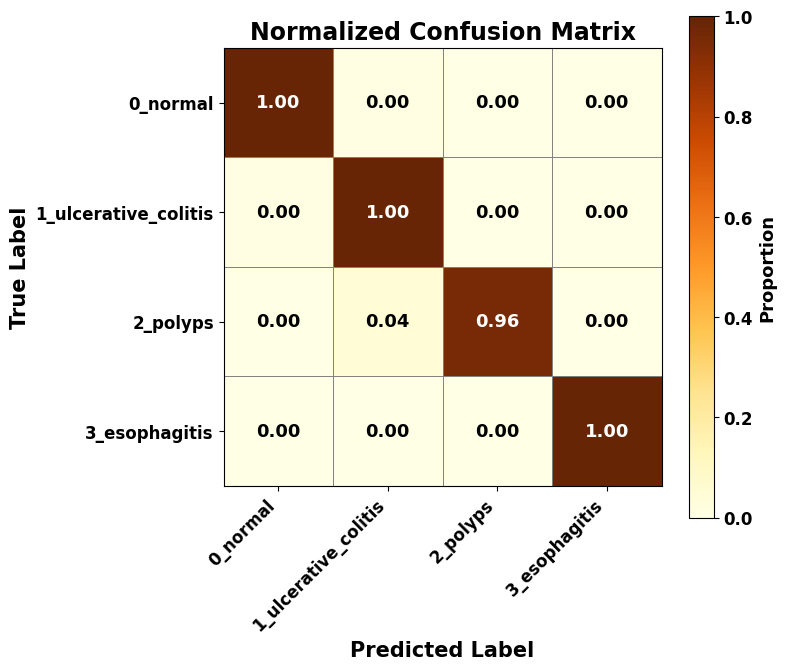


================ PER-CLASS METRICS ================

Class           Precision    Recall  F1-score   Support
-----------------------------------------------------------------
0_normal            0.996     0.996     0.996       225
1_ulcerative_colitis     0.953     0.996     0.974       225
2_polyps            1.000     0.956     0.977       225
3_esophagitis       1.000     1.000     1.000       225

================ OVERALL METRICS ================

Accuracy           : 0.9867
Precision (Macro)  : 0.9872
Recall (Macro)     : 0.9867
F1-score (Macro)   : 0.9867

================ CLASSIFICATION REPORT ================

                      precision    recall  f1-score   support

            0_normal      0.996     0.996     0.996       225
1_ulcerative_colitis      0.953     0.996     0.974       225
            2_polyps      1.000     0.956     0.977       225
       3_esophagitis      1.000     1.000     1.000       225

            accuracy                          0.987       900

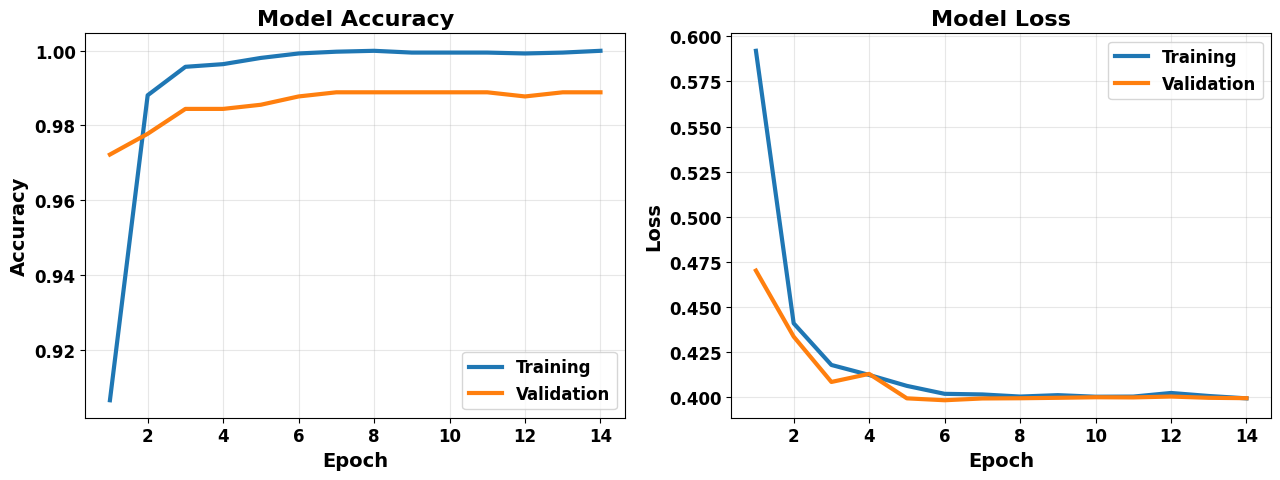

In [3]:
# =================== IMPORTS ===================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score
)

# =================== GLOBAL FONT SETTINGS ===================
plt.rcParams.update({
    'font.size': 13,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# =================== PREDICTIONS ===================
# IMPORTANT: test_generator MUST have shuffle=False
y_true = test_generator.classes

y_pred_probs = model.predict(
    test_generator,
    steps=len(test_generator),
    verbose=1
)
y_pred = np.argmax(y_pred_probs, axis=1)

# =================== FIX CLASS LABEL ORDER ===================
class_indices = test_generator.class_indices
class_labels = [cls for cls, idx in sorted(class_indices.items(), key=lambda x: x[1])]
num_classes = len(class_labels)

# =================== CONFUSION MATRIX (RAW) ===================
cm = confusion_matrix(y_true, y_pred)

print("\n================ CONFUSION MATRIX (RAW COUNTS) ================\n")
print(cm)

# =================== CONFUSION MATRIX (NORMALIZED) ===================
cm_norm = np.divide(
    cm.astype(np.float64),
    cm.sum(axis=1, keepdims=True),
    where=cm.sum(axis=1, keepdims=True) != 0
)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_norm, cmap='YlOrBr', vmin=0, vmax=1)

cbar = plt.colorbar(im)
cbar.set_label("Proportion", fontsize=13, fontweight='bold')

plt.xticks(range(num_classes), class_labels, rotation=45, ha='right', fontweight='bold')
plt.yticks(range(num_classes), class_labels, fontweight='bold')

plt.xlabel("Predicted Label", fontsize=15, fontweight='bold')
plt.ylabel("True Label", fontsize=15, fontweight='bold')
plt.title("Normalized Confusion Matrix", fontsize=17, fontweight='bold')

# Grid lines
for i in range(num_classes + 1):
    plt.axhline(i - 0.5, color='gray', linewidth=0.7)
    plt.axvline(i - 0.5, color='gray', linewidth=0.7)

# Cell annotations
for i in range(num_classes):
    for j in range(num_classes):
        value = cm_norm[i, j]
        color = 'white' if value > 0.6 else 'black'
        plt.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            fontsize=13,
            fontweight='bold',
            color=color
        )

plt.tight_layout()
plt.show()

# =================== PER-CLASS METRICS ===================
precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

print("\n================ PER-CLASS METRICS ================\n")
print(f"{'Class':15s} {'Precision':>9s} {'Recall':>9s} {'F1-score':>9s} {'Support':>9s}")
print("-" * 65)

for i, cls in enumerate(class_labels):
    print(f"{cls:15s} {precision[i]:9.3f} {recall[i]:9.3f} {f1[i]:9.3f} {support[i]:9d}")

# =================== OVERALL METRICS ===================
accuracy = accuracy_score(y_true, y_pred)

print("\n================ OVERALL METRICS ================\n")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision (Macro)  : {precision.mean():.4f}")
print(f"Recall (Macro)     : {recall.mean():.4f}")
print(f"F1-score (Macro)   : {f1.mean():.4f}")

# =================== CLASSIFICATION REPORT ===================
print("\n================ CLASSIFICATION REPORT ================\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_labels,
    digits=3,
    zero_division=0
))

# =================== TRAINING CURVES (NaN-SAFE) ===================
def plot_history(history):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(13, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training', linewidth=3)
    if len(val_acc) > 0:
        plt.plot(epochs, val_acc, label='Validation', linewidth=3)
    plt.title('Model Accuracy', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training', linewidth=3)
    if len(val_loss) > 0:
        plt.plot(epochs, val_loss, label='Validation', linewidth=3)
    plt.title('Model Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14, fontweight='bold')
    plt.ylabel('Loss', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)
